#  Result analysis Notebook

**Description**

This notebook is used for further prediction result analysis. This notebook further looks on overlap percentage between ground truth and prediction of each group of green space size. Pixel count is used here.

*The overlap percentage shown in the following analysis is calculated as the proportion of ground truth area that is covered by the prediction.*

**Input folder(s)/file(s)**

4 files
- Public Urban Green Spaces (PUGS) ground truth (geojson file) (`dresden_pugs_gt_undissolved.geojson`)
- Public Urban Green Spaces (PUGS) ground truth (raster) (`clipped_dresden_pugs_gt.geotiff`)
- Prediction output from using sentinel-2 image (`clipped_pred_v0.geotiff`)
- Prediction output from using sentinel-2 image and PUGS binary mask derived from OSM (`clipped_pred_v1.geotiff`)

**Output folder(s)/file(s)**

1 file
-  The bar chart compare recall value of each green space size group and different set of inputs (`pugs_size_analysis.png`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_ground_truth.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb
- 6_model_training.ipynb
- 7_model_evaluation.ipynb

**Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

### 1. Import libraries and load config

It can take up to 5-6 mins to complete this section.

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import numpy as np
from rasterstats import zonal_stats
from pugs_detection.ground_truth import merge_overlapping_polygons
from pugs_detection.plots import plot_result_analysis

In [2]:
# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

### 2. Set variables

In [3]:
# Graph output Paths
seed = config["general"]["seed"]
graph_output_path = config["paths"]["analysis_graph_path"].format(seed=seed)


### 3. Group area in ground truth by size

Categorize by type of green spaces

|  Type  | Size (ha) |
| ------ | --------- |
| Pocket park | <= 0.4 |
| Neighbourhood park | (0.4, 3] |
| Community park | (3, 10] |
| Urban/District park | (10, 80] |
| Regional park | > 80 |

In [4]:
gt_gdf = gpd.read_file(config["paths"]["gt_undissolved_path"])

In [5]:
# Merge overlapping polygons in the ground truth GeoDataFrame to avoid double-counting overlapping areas
# We use a threshold of 0.5 to determine if two polygons should be merged based on their intersection over union (IoU).
merged_gdf = merge_overlapping_polygons(gt_gdf, threshold=0.5)

# Calculate area and group by size
merged_gdf["area_m2"] = merged_gdf.geometry.area

In [6]:
# Assign bins and labels for area groups
bins = [0, 4000, 30000, 100000, 800000, merged_gdf["area_m2"].max()]
labels = ["<= 0.4", "(0.4, 3]", "(3, 10]", "(10, 80]", "> 80"]
merged_gdf["area_group"] = pd.cut(merged_gdf["area_m2"], bins=bins, labels=labels, include_lowest=True)

In [7]:
merged_gdf

,merged_ids,geometry,area_m2,area_group
0,[1],"POLYGON ((407724.344 5652810.146, 407715.219 5...",15786.025473,"(0.4, 3]"
1,"[2033, 2]","POLYGON ((408110.169 5652041.679, 408118.878 5...",5145.510703,"(0.4, 3]"
2,[3],"POLYGON ((407772.206 5651899.198, 407740.757 5...",14415.849657,"(0.4, 3]"
3,[4],"POLYGON ((407914.278 5651927.418, 407878.411 5...",15471.960657,"(0.4, 3]"
4,[5],"POLYGON ((407940.262 5651978.202, 407920.845 5...",4968.877225,"(0.4, 3]"
...,...,...,...,...
1790,[2081],"POLYGON ((414725.58 5651620.862, 414711.316 56...",997.002121,<= 0.4
1791,[2082],"MULTIPOLYGON (((407254.944 5657580.279, 407254...",752.398577,<= 0.4
1792,[2083],"MULTIPOLYGON (((414297.078 5664017.838, 414298...",1705.859616,<= 0.4
1793,[2087],"POLYGON ((421676.435 5653306.616, 421676.447 5...",589.502916,<= 0.4


In [8]:
print("Total PUGS", merged_gdf["area_m2"].count())
print("min area: ", merged_gdf["area_m2"].min())
print("max area: ", merged_gdf["area_m2"].max())

Total PUGS 1795
min area:  104.38963594453043
max area:  21319754.980819084


In [9]:
# how many polygons in each group - This is in the GT
group_counts = merged_gdf["area_group"].value_counts().sort_index()
group_counts

area_group
<= 0.4       531
(0.4, 3]    1018
(3, 10]      150
(10, 80]      88
> 80           8
Name: count, dtype: int64

In [ ]:
# merged_gdf.explore(column="area_group", cmap="Set1", width="50%", height="400px")

In [11]:
# Dissolve polygons by area group
dissolved_by_group = merged_gdf.dissolve(by="area_group", as_index=False)

In [12]:
dissolved_by_group

,area_group,geometry,merged_ids,area_m2
0,<= 0.4,"MULTIPOLYGON (((404372.437 5654271.712, 404330...",[11],2.658125e+03
1,"(0.4, 3]","MULTIPOLYGON (((406684.976 5653066.565, 406679...",[1],1.578603e+04
2,"(3, 10]","MULTIPOLYGON (((408615.63 5651144.08, 408616.5...",[12],4.609862e+04
3,"(10, 80]","MULTIPOLYGON (((409108.743 5651217.754, 409073...",[13],1.105415e+05
4,> 80,"MULTIPOLYGON (((427468.233 5656415.658, 427443...",[373],2.131975e+07


In [ ]:
dissolved_by_group.explore(column="area_group", cmap="Set1", legend=True, name="Dissolved by Area Group", width="50%", height="300px")

In [14]:
# save the output
dissolved_by_group.to_file(config["paths"]["dissolved_by_area_group_gt_path"], driver="GeoJSON")

### 4. Calculate overlap percentage between ground truth and prediction of each PUGS area group

In [15]:
# Derive green space of each area group from ground truth dataset
stats_gt = zonal_stats(
    dissolved_by_group,  # vector
    config["paths"]["clipped_gt_raster_path"],  # raster
    stats=["sum", "count"],
    nodata=-9999,  # treat -9999 as nodata
)

stats_gt_df = pd.DataFrame(stats_gt)

stats_gt_df = pd.concat(
    [dissolved_by_group[["area_group", "geometry"]], stats_gt_df], axis=1
)

In [16]:
stats_gt_df

,area_group,geometry,count,sum
0,<= 0.4,"MULTIPOLYGON (((404372.437 5654271.712, 404330...",9600,9600.0
1,"(0.4, 3]","MULTIPOLYGON (((406684.976 5653066.565, 406679...",112338,112338.0
2,"(3, 10]","MULTIPOLYGON (((408615.63 5651144.08, 408616.5...",79500,79500.0
3,"(10, 80]","MULTIPOLYGON (((409108.743 5651217.754, 409073...",212904,212904.0
4,> 80,"MULTIPOLYGON (((427468.233 5656415.658, 427443...",510409,510409.0


#### 4.1. Find Recall value based on PUGS size (using Sentinel-2 image + PUGS binary mask derived from OSM as input)

$$\text{Recall (\%)} = \frac{\text{TP}}{\text{TP+FN}} \times 100 = \frac{\text{Overlap area between GT and pred}}{\text{Total area of Ground truth}} \times 100$$

*GT = ground truth, pred = prediction result*

In [17]:
# Derive green space of each area group from OSM binary prediction raster
# Manually configure the best OSM prediction raster path based on the seed value
# config["paths"]["with_osm_pred_raster_path"].format(seed=seed),  # raster
# set the version of the best OSM prediction raster to use for analysis. This is based on the results of the experiments in the previous notebook.
osm_version = 1
best_osm_pred_raster_path = config["paths"]["pred_raster_path"].format(seed=seed, version=osm_version)  
print(f"Using OSM prediction raster: {best_osm_pred_raster_path}")
stats_pred_osm = zonal_stats(
    dissolved_by_group,  # vector
    best_osm_pred_raster_path,  # raster
    stats=["sum", "count"],
    nodata=-9999,  # treat -9999 as nodata
)

stats_pred_osm_df = pd.DataFrame(stats_pred_osm)

stats_pred_osm_df = pd.concat(
    [dissolved_by_group[["area_group", "geometry"]], stats_pred_osm_df], axis=1
)

Using OSM prediction raster: ../s42/results/clipped_prediction/clipped_pred_v1.geotiff


In [18]:
stats_pred_osm_df

,area_group,geometry,count,sum
0,<= 0.4,"MULTIPOLYGON (((404372.437 5654271.712, 404330...",9600,2940.0
1,"(0.4, 3]","MULTIPOLYGON (((406684.976 5653066.565, 406679...",112338,69343.0
2,"(3, 10]","MULTIPOLYGON (((408615.63 5651144.08, 408616.5...",79500,68332.0
3,"(10, 80]","MULTIPOLYGON (((409108.743 5651217.754, 409073...",212904,202873.0
4,> 80,"MULTIPOLYGON (((427468.233 5656415.658, 427443...",510409,505054.0


In [19]:
# compute the overlap percentage (recall) of OSM prediction with respect to ground truth for each area group
overlap_pct_osm_area_group = {}
for i in range(len(stats_gt_df)):
    gt = stats_gt_df.iloc[i]
    pred = stats_pred_osm_df.iloc[i]
    overlap_pct = (pred["sum"] / gt["sum"]) * 100
    overlap_pct_osm_area_group[gt["area_group"]] = overlap_pct

In [20]:
overlap_pct_osm_area_group

{'<= 0.4': np.float64(30.625000000000004),
 '(0.4, 3]': np.float64(61.72710925955598),
 '(3, 10]': np.float64(85.95220125786163),
 '(10, 80]': np.float64(95.28848682974485),
 '> 80': np.float64(98.9508413840665)}

### 4.2. Find Recall value per instance based on PUGS size (using Sentinel-2 image + PUGS binary mask derived from OSM as input)

$$\text{Recall (\%)} = \frac{\text{TP}}{\text{TP+FN}} \times 100 = \frac{\text{Polygons detected within a threshold}}{\text{Total GT polygons}} \times 100$$

*GT = ground truth, pred = prediction result*

In [21]:
# Calculate the stats using the undissolved ground truth polygons merged_gdf
# count is the number of pixels in the raster that fall within the polygon
# mean is the mean value of the pixels in the raster that fall within the polygon
# as the prediction raster is binary, the mean is the fraction of pixels that are predicted as positive within the polygon


stats_in_gt_osm = zonal_stats(
    merged_gdf,  # vector
    # config["paths"]["with_osm_pred_raster_path"].format(seed=seed),  # raster
    best_osm_pred_raster_path,  # raster
    stats=["mean", "count"],
    nodata=-9999,  # treat -9999 as nodata
)
stats_in_gt_df_osm = pd.DataFrame(stats_in_gt_osm)
stats_in_gt_df_osm = pd.concat(
    [merged_gdf[["geometry","area_group", "area_m2"]], stats_in_gt_df_osm], axis=1
)
COV_THR = 0.5
stats_in_gt_df_osm['detected'] = stats_in_gt_df_osm["mean"].fillna(0) >= COV_THR
per_class_detection_osm = (stats_in_gt_df_osm.groupby("area_group", observed=True)["detected"]
                       .agg(n="size", n_detected="sum", recall="mean").reset_index()
                       )                
print(per_class_detection_osm)


  area_group     n  n_detected    recall
0     <= 0.4   531         125  0.235405
1   (0.4, 3]  1018         627  0.615914
2    (3, 10]   150         137  0.913333
3   (10, 80]    88          87  0.988636
4       > 80     8           8  1.000000


### 4.3. Find Recall value based on PUGS size (using only Sentinel-2 image as input)

$$\text{Recall (\%)} = \frac{\text{TP}}{\text{TP+FN}} \times 100 = \frac{\text{Overlap area between GT and pred}}{\text{Total area of Ground truth}} \times 100$$

*GT = ground truth, pred = prediction result*

In [22]:
sentinel_version = 12
best_sentinel_pred_raster_path = config["paths"]["pred_raster_path"].format(seed=seed, version=sentinel_version)  
print(f"Using Sentinel prediction raster: {best_sentinel_pred_raster_path}")
# config["paths"]["sentinel_pred_raster_path"].format(seed=seed),  # raster
stats_pred_sat = zonal_stats(
    dissolved_by_group,  # vector
    best_sentinel_pred_raster_path,  # raster
    stats=["sum", "count"],
    nodata=-9999,  # treat -9999 as nodata
)

stats_pred_sat_df = pd.DataFrame(stats_pred_sat)

stats_pred_sat_df = pd.concat(
    [dissolved_by_group[["area_group", "geometry"]], stats_pred_sat_df], axis=1
)

Using Sentinel prediction raster: ../s42/results/clipped_prediction/clipped_pred_v12.geotiff


In [23]:
stats_pred_sat_df

,area_group,geometry,count,sum
0,<= 0.4,"MULTIPOLYGON (((404372.437 5654271.712, 404330...",9600,2272.0
1,"(0.4, 3]","MULTIPOLYGON (((406684.976 5653066.565, 406679...",112338,67008.0
2,"(3, 10]","MULTIPOLYGON (((408615.63 5651144.08, 408616.5...",79500,67322.0
3,"(10, 80]","MULTIPOLYGON (((409108.743 5651217.754, 409073...",212904,199901.0
4,> 80,"MULTIPOLYGON (((427468.233 5656415.658, 427443...",510409,506878.0


In [24]:
overlap_pct_sat_area_group = {}
for i in range(len(stats_gt_df)):
    gt = stats_gt_df.iloc[i]
    pred = stats_pred_sat_df.iloc[i]
    overlap_pct = (pred["sum"] / gt["sum"]) * 100
    overlap_pct_sat_area_group[gt["area_group"]] = overlap_pct

In [25]:
overlap_pct_sat_area_group

{'<= 0.4': np.float64(23.666666666666668),
 '(0.4, 3]': np.float64(59.648560593921914),
 '(3, 10]': np.float64(84.6817610062893),
 '(10, 80]': np.float64(93.89255251193026),
 '> 80': np.float64(99.30820185380743)}

### 4.4. Find Recall value per instance based on PUGS size (using Sentinel-2 image)

$$\text{Recall (\%)} = \frac{\text{TP}}{\text{TP+FN}} \times 100 = \frac{\text{Polygons detected within a threshold}}{\text{Total GT polygons}} \times 100$$

*GT = ground truth, pred = prediction result*

In [26]:

stats_in_gt = zonal_stats(
    merged_gdf,  # vector
    # config["paths"]["sentinel_pred_raster_path"].format(seed=seed),  # raster
    best_sentinel_pred_raster_path,  # raster
    stats=["mean", "count"],
    nodata=-9999,  # treat -9999 as nodata
)

stats_in_gt_df = pd.DataFrame(stats_in_gt)

stats_in_gt_df = pd.concat(
    [merged_gdf[["geometry","area_group", "area_m2"]], stats_in_gt_df], axis=1
)
COV_THR = 0.5
stats_in_gt_df['detected'] = stats_in_gt_df["mean"].fillna(0) >= COV_THR
per_class_detection = (stats_in_gt_df.groupby("area_group", observed=True)["detected"]
                       .agg(n="size", n_detected="sum", recall="mean").reset_index()
                       )                


In [27]:
per_class_detection

,area_group,n,n_detected,recall
0,<= 0.4,531,93,0.175141
1,"(0.4, 3]",1018,592,0.581532
2,"(3, 10]",150,136,0.906667
3,"(10, 80]",88,85,0.965909
4,> 80,8,8,1.000000


In [28]:
# --- Merge on area_group (keeps category order) ---
df = per_class_detection.merge(
    per_class_detection_osm,
    on=["area_group", "n"],
    suffixes=("_no_osm", "_osm"),
)

# --- Improvement metrics ---
df["extra_detected"] = df["n_detected_osm"] - df["n_detected_no_osm"]

# Absolute improvement in recall, in percentage points
df["recall_gain_pp"] = (df["recall_osm"] - df["recall_no_osm"]) * 100

# Relative improvement in recall, in %
df["recall_gain_rel_%"] = (
    (df["recall_osm"] - df["recall_no_osm"]) / df["recall_no_osm"] * 100
)

# --- Optional: overall (all categories pooled) ---
total = pd.DataFrame({
    "area_group": ["Overall"],
    "n": [df["n"].sum()],
    "n_detected_no_osm": [df["n_detected_no_osm"].sum()],
    "n_detected_osm": [df["n_detected_osm"].sum()],
})
total["recall_no_osm"] = total["n_detected_no_osm"] / total["n"]
total["recall_osm"] = total["n_detected_osm"] / total["n"]
total["extra_detected"] = total["n_detected_osm"] - total["n_detected_no_osm"]
total["recall_gain_pp"] = (total["recall_osm"] - total["recall_no_osm"]) * 100
total["recall_gain_rel_%"] = (
    (total["recall_osm"] - total["recall_no_osm"]) / total["recall_no_osm"] * 100
)

result = pd.concat([df, total], ignore_index=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print(result.round(3).to_string(index=False))
result.to_csv(config["paths"]["per_instance_recall_path_global"].format(seed=seed), index=False)

area_group    n  n_detected_no_osm  recall_no_osm  n_detected_osm  recall_osm  extra_detected  recall_gain_pp  recall_gain_rel_%
    <= 0.4  531                 93          0.175             125       0.235              32           6.026             34.409
  (0.4, 3] 1018                592          0.582             627       0.616              35           3.438              5.912
   (3, 10]  150                136          0.907             137       0.913               1           0.667              0.735
  (10, 80]   88                 85          0.966              87       0.989               2           2.273              2.353
      > 80    8                  8          1.000               8       1.000               0           0.000              0.000
   Overall 1795                914          0.509             984       0.548              70           3.900              7.659


### 5. Plot the result graph

In [29]:
area_groups = stats_gt_df["area_group"].unique()

df = pd.DataFrame(
    {
        "Area Group": area_groups,
        "Sentinel-2+OSM PUGS binary mask": [
            overlap_pct_osm_area_group[ag] for ag in area_groups
        ],
        "Sentinel-2 Only": [overlap_pct_sat_area_group[ag] for ag in area_groups],
    }
)

# Melt the DataFrame for plotting
df_melted = df.melt(
    id_vars="Area Group", var_name="Input Set", value_name="Overlap Percentage"
)
df

,Area Group,Sentinel-2+OSM PUGS binary mask,Sentinel-2 Only
0,<= 0.4,30.625000,23.666667
1,"(0.4, 3]",61.727109,59.648561
2,"(3, 10]",85.952201,84.681761
3,"(10, 80]",95.288487,93.892553
4,> 80,98.950841,99.308202


In [30]:
total_area = merged_gdf["area_m2"].sum()

# Calculate total area by category (in hectares)
area_by_category = (
    merged_gdf.groupby("area_group", observed=True)["area_m2"].sum() / 10000
)  # Convert m² to ha

# Create summary DataFrame with both hectares and percentages
total_area = area_by_category.sum()
summary_df = pd.DataFrame(
    {
        "Total Area (ha)": area_by_category,
        "Percentage (%)": (area_by_category / total_area) * 100,
    }
)

# Sort by green space size category
summary_df = summary_df.reindex(labels).reset_index()

summary_df

,area_group,Total Area (ha),Percentage (%)
0,<= 0.4,96.474838,1.042068
1,"(0.4, 3]",1128.575944,12.190254
2,"(3, 10]",796.165442,8.599739
3,"(10, 80]",2131.236173,23.020436
4,> 80,5105.565920,55.147503


### The key findings from result
- Model performance improves as green space size increases.
- The model that uses both Sentinel-2 imagery and PUGS binary mask from OSM as input outperforms the one using only Sentinel-2 imagery.
- Regional parks are easiest to detect and both models achieve approximately 99% of recall.
- Small PUGS (e.g., pocket and neighbourhood parks) are more difficult to detect and have lower recall values.
- Regional parks dominate total green space area but make up only a small fraction of the total number of PUGS.
- In contrast, small PUGS has the higheest numbers in terms of PUGS count but contribute little to total area.
- The most significant performance gap between two models gain from using additional data from OSM is seen in small PUGS, especially pocket parks.

../s42/reports/figures/others


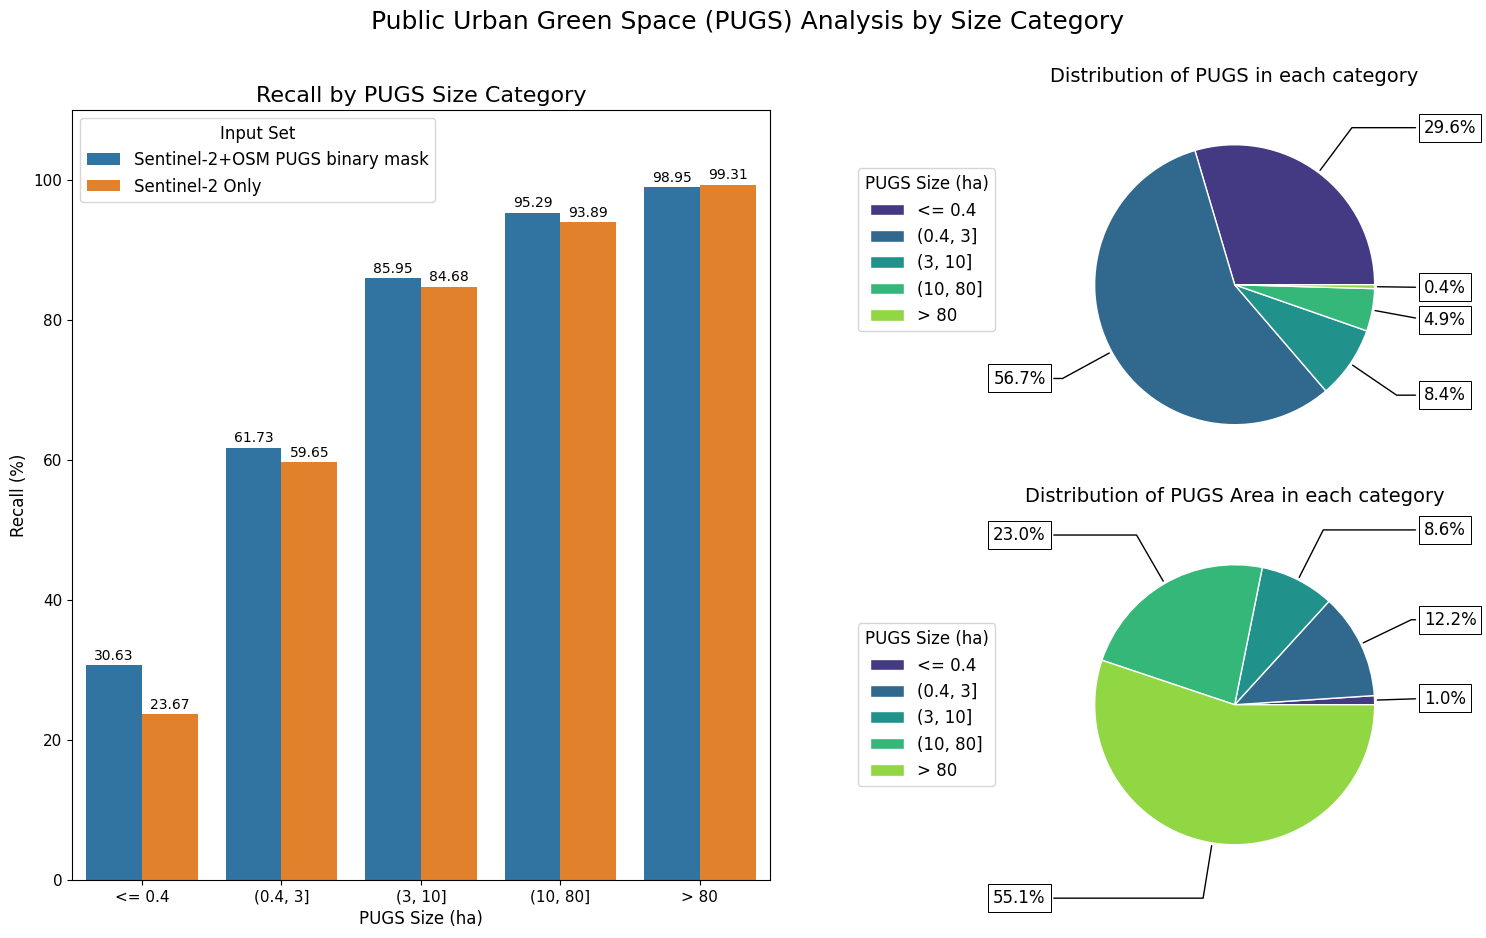

In [31]:
print(os.path.dirname(graph_output_path))
if not os.path.exists(os.path.dirname(graph_output_path)):
    os.makedirs(os.path.dirname(graph_output_path))
plot_result_analysis(area_groups, df_melted, summary_df, group_counts, graph_output_path)